# EDA on Retail Sales Data

**Goal:** Explore a retail sales dataset to find patterns, customer trends, and business insights.

**Tools:** Python, pandas, matplotlib, seaborn


## 0. Dataset

Retail order data (`train.csv`, Superstore dataset).

**Columns:** Order/Ship dates, Ship Mode, Customer info, Segment, Location, Product info, Category, Sub-Category, Sales.


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Data Loading & Initial Inspection

In [3]:
DATA_DIR = "data"

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if not csv_files:
    csv_files = glob.glob("*.csv")

print("CSV files found:")
for f in csv_files:
    print(" -", f)

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found. Place 'train.csv' in a 'data/' folder (or next to this "
        "notebook) before re-running."
    )

df = pd.read_csv(csv_files[0])
df.head()

CSV files found:
 - train.csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print("Shape:", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)

Shape: (9800, 18)

Column dtypes:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [5]:
print("Null values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Null values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows: 0


**Observation:** 9,800 rows, 18 columns, no duplicates. Only `Postal Code` has a few missing values (11 rows) — too small to matter, so we leave them as-is.


### Type Conversion

In [6]:
# Order Date / Ship Date are stored as DD/MM/YYYY strings — convert to proper datetimes
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Feature engineering: useful derived fields for time-series and correlation analysis
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Quarter"] = df["Order Date"].dt.quarter
df["Order_Weekday"] = df["Order Date"].dt.day_name()
df["Shipping_Delay_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df.dtypes

Row ID                          int64
Order ID                       object
Order Date             datetime64[ns]
Ship Date              datetime64[ns]
Ship Mode                      object
Customer ID                    object
Customer Name                  object
Segment                        object
Country                        object
City                           object
State                          object
Postal Code                   float64
Region                         object
Product ID                     object
Category                       object
Sub-Category                   object
Product Name                   object
Sales                         float64
Order_Year                      int32
Order_Month                     int32
Order_Quarter                   int32
Order_Weekday                  object
Shipping_Delay_Days             int64
dtype: object

## 2. Descriptive Statistics

In [7]:
numeric_cols = ["Sales", "Shipping_Delay_Days", "Postal Code"]

desc_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Std Dev": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
}).round(2)

desc_stats

,Mean,Median,Mode,Std Dev,Min,Max
Sales,230.77,54.49,12.96,626.65,0.44,22638.48
Shipping_Delay_Days,3.96,4.00,4.00,1.75,0.00,7.00
Postal Code,55273.32,58103.00,10035.00,32041.22,1040.00,99301.00


**Observation:** Average sale is ~$230, but the median is only ~$54 — meaning most orders are small, and a few big orders pull the average up. Shipping takes about 4 days on average.


## 3. Time Series Analysis

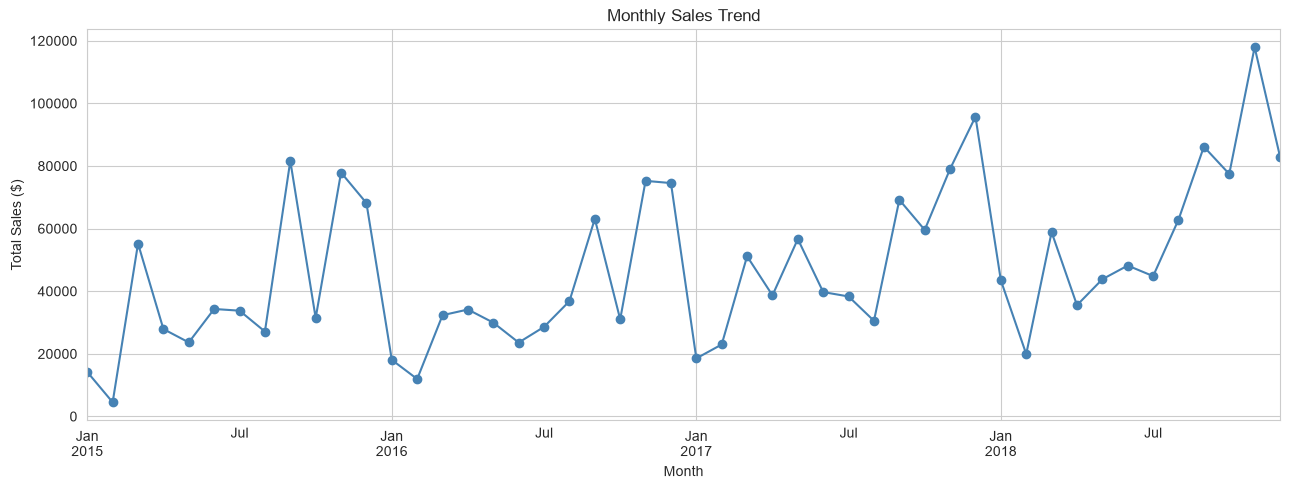

In [8]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
)

plt.figure(figsize=(13, 5))
monthly_sales.plot(marker="o", color="steelblue")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

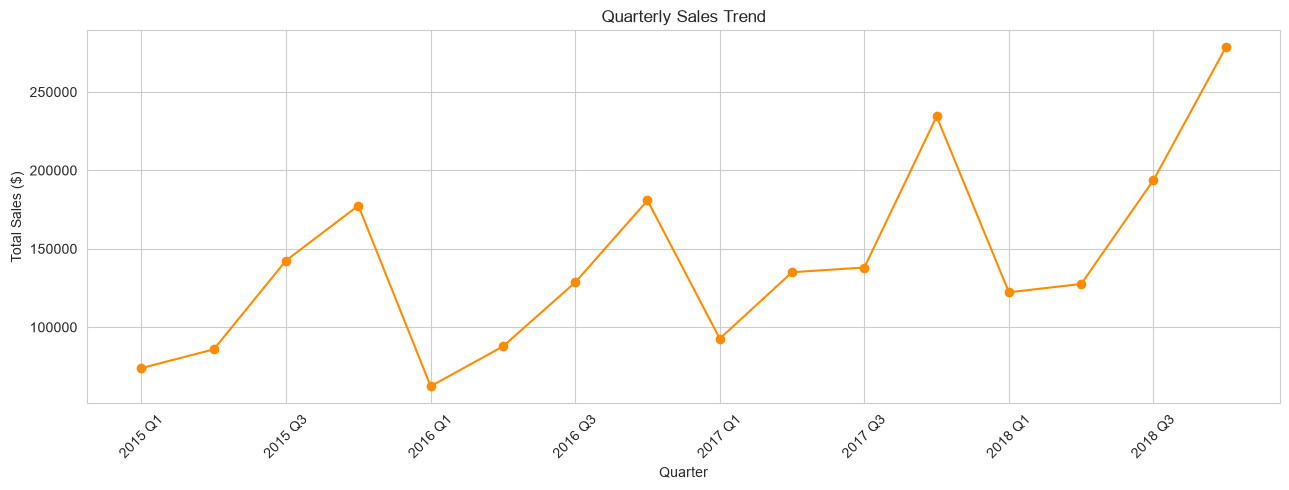

In [9]:
quarterly_sales = (
    df.groupby(["Order_Year", "Order_Quarter"])["Sales"]
      .sum()
)
quarterly_sales.index = [f"{y} Q{q}" for y, q in quarterly_sales.index]

plt.figure(figsize=(13, 5))
quarterly_sales.plot(marker="o", color="darkorange")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Sales spike every year in Q4 (Nov-Dec), likely due to the holiday season, and dip in Q1. Overall, sales are trending upward year over year — the business is growing.


## 4. Customer Analysis

*(No Age/Gender data available — we use Segment and Region instead.)*


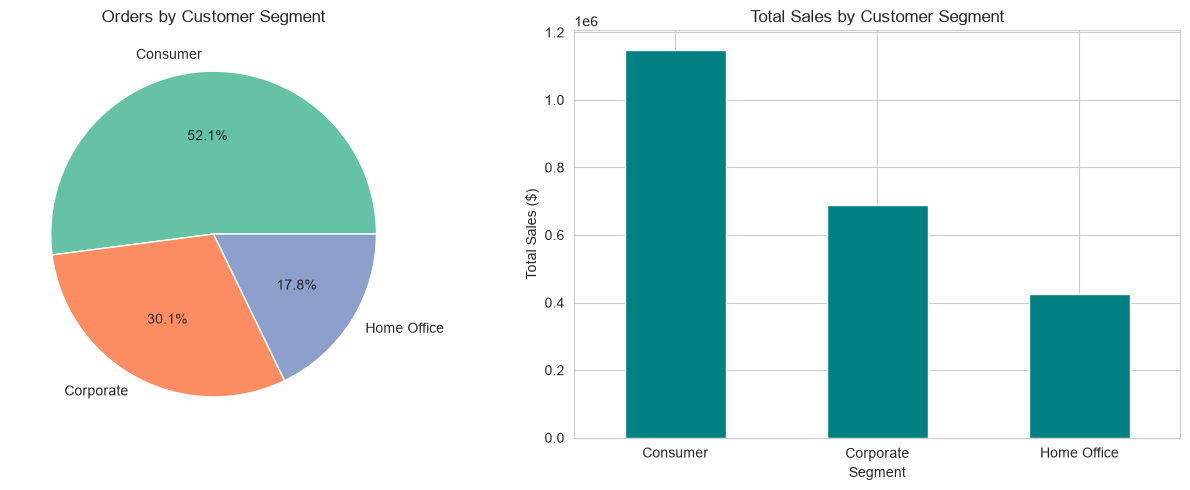

In [10]:
segment_counts = df["Segment"].value_counts()
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(segment_counts, labels=segment_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[0].set_title("Orders by Customer Segment")

segment_sales.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Total Sales by Customer Segment")
axes[1].set_ylabel("Total Sales ($)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

C:\Users\sudar\AppData\Local\Temp\ipykernel_11872\4079083904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette="Blues_d")


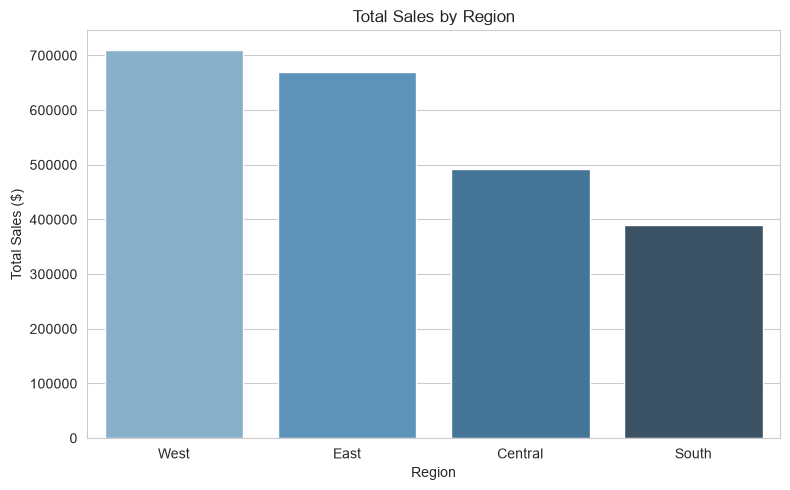

In [11]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="Blues_d")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

**Observation:** The `Consumer` segment brings in the most orders and revenue — mainly because it has more orders, not bigger ones. `West` and `East` regions sell the most; `South` lags behind.


## 5. Product Analysis

C:\Users\sudar\AppData\Local\Temp\ipykernel_11872\1809366793.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_products.values, y=top10_products.index, palette="viridis")


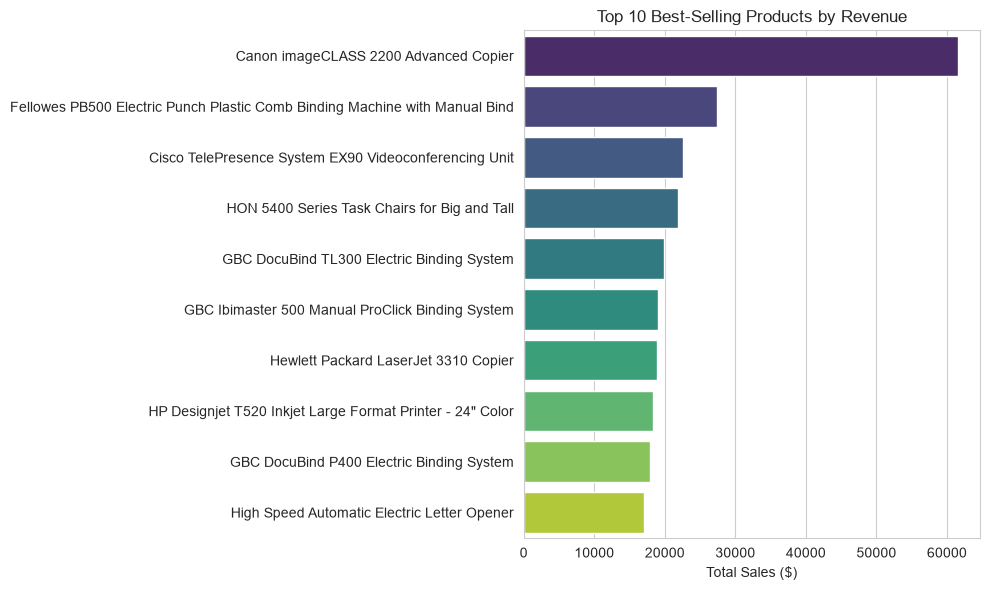

In [12]:
top10_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_products.values, y=top10_products.index, palette="viridis")
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Total Sales ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

*Note: No `Quantity` column exists, so "best-selling" here means highest revenue.*

**Observation:** Top products are pricier equipment (copiers, chairs, binding machines), not everyday cheap items. Even Office Supplies has some high-revenue items, despite usually being a low-ticket category overall.


C:\Users\sudar\AppData\Local\Temp\ipykernel_11872\1742207833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="magma")


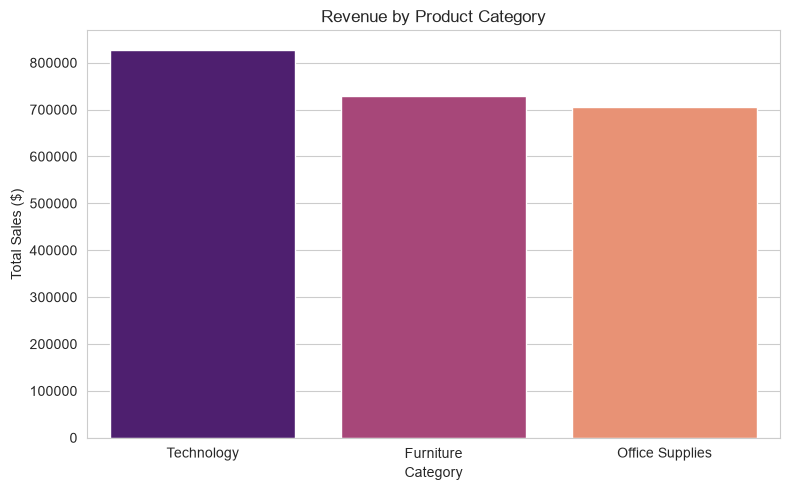

In [13]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="magma")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

**Observation:** `Technology` earns the most revenue despite fewer orders — its orders are just bigger. `Office Supplies` has the most orders but the smallest ticket size per order.


## 6. Correlation Matrix Heatmap

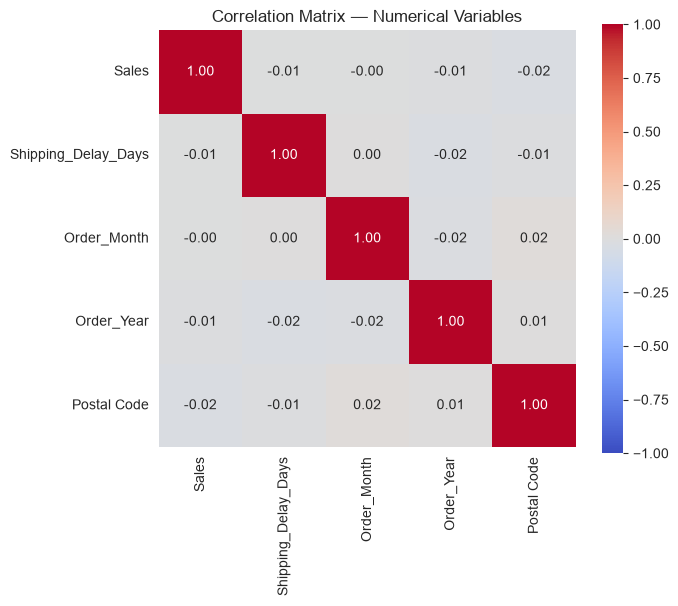

In [14]:
corr_cols = ["Sales", "Shipping_Delay_Days", "Order_Month", "Order_Year", "Postal Code"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.show()

**Observation:** No numeric column (shipping delay, date, location) strongly correlates with `Sales` — sale amount mostly depends on *which product* was bought, not these other factors.


## 7. Additional Insight — Order Value by Shipping Speed

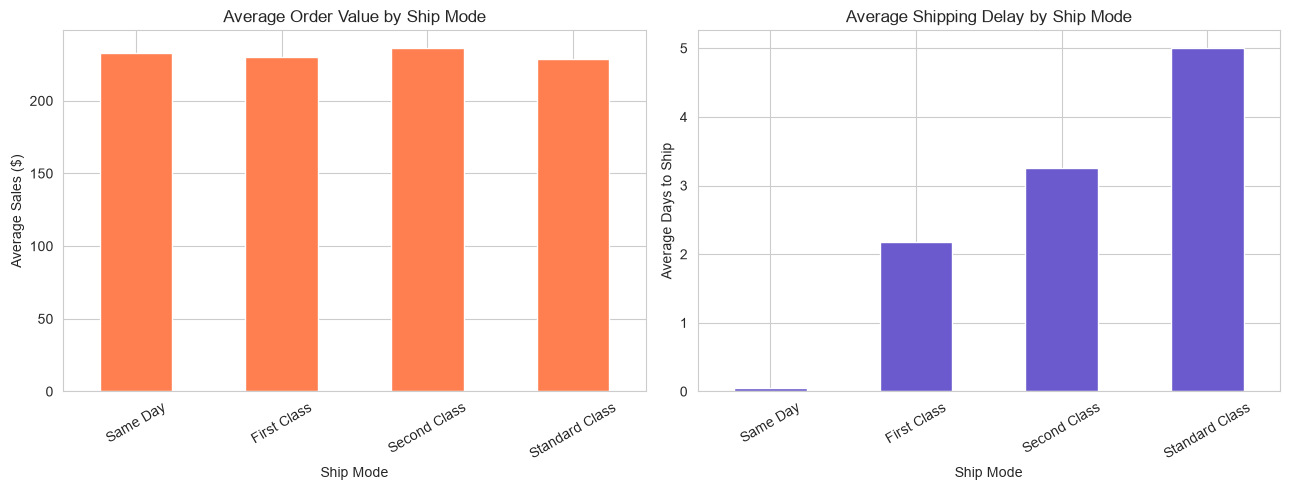

In [15]:
ship_mode_order = ["Same Day", "First Class", "Second Class", "Standard Class"]
avg_sales_by_ship = df.groupby("Ship Mode")["Sales"].mean().reindex(ship_mode_order)
avg_delay_by_ship = df.groupby("Ship Mode")["Shipping_Delay_Days"].mean().reindex(ship_mode_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

avg_sales_by_ship.plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Average Order Value by Ship Mode")
axes[0].set_ylabel("Average Sales ($)")
axes[0].tick_params(axis="x", rotation=30)

avg_delay_by_ship.plot(kind="bar", ax=axes[1], color="slateblue")
axes[1].set_title("Average Shipping Delay by Ship Mode")
axes[1].set_ylabel("Average Days to Ship")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Observation:** Faster shipping doesn't mean bigger orders — `Same Day` orders aren't larger than `Standard Class` ones. Customers don't seem to pick fast shipping because they're spending more.


## 8. Conclusion & Recommendations

**Key findings:**
- Sales are skewed — a few big orders (Technology, Furniture) drive most revenue.
- Clear seasonal pattern: sales peak every Q4, and grow year over year.
- `Technology` has the highest revenue per order; `Office Supplies` has the most orders but lowest value each.
- `West`/`East` regions outperform `South`.
- Shipping speed doesn't affect order size.

**Recommendations:**
1. **Plan ahead for Q4** — stock up on Technology/Furniture and add staff before the holiday rush.
2. **Investigate the South region's weak sales** — check if it's a market size issue or a sales/marketing gap.
3. **Rethink premium shipping pricing** — since fast shipping isn't tied to bigger orders, consider a minimum order value for free/expedited shipping.
4. **Bundle Office Supplies products** — boost average order value in this high-volume, low-ticket category.
